# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

In [ ]:
df_california = pd.read_csv('california_dataset.csv')

In [ ]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

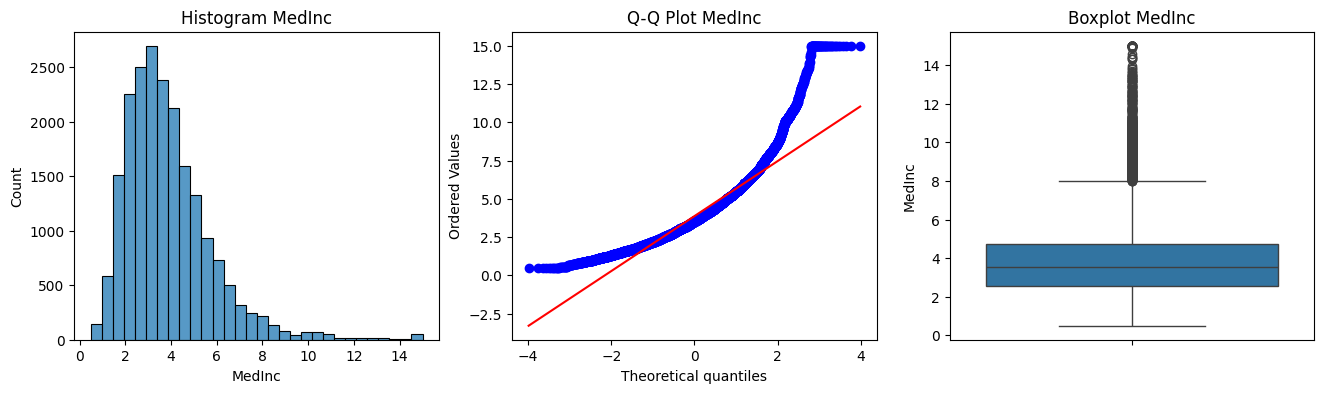

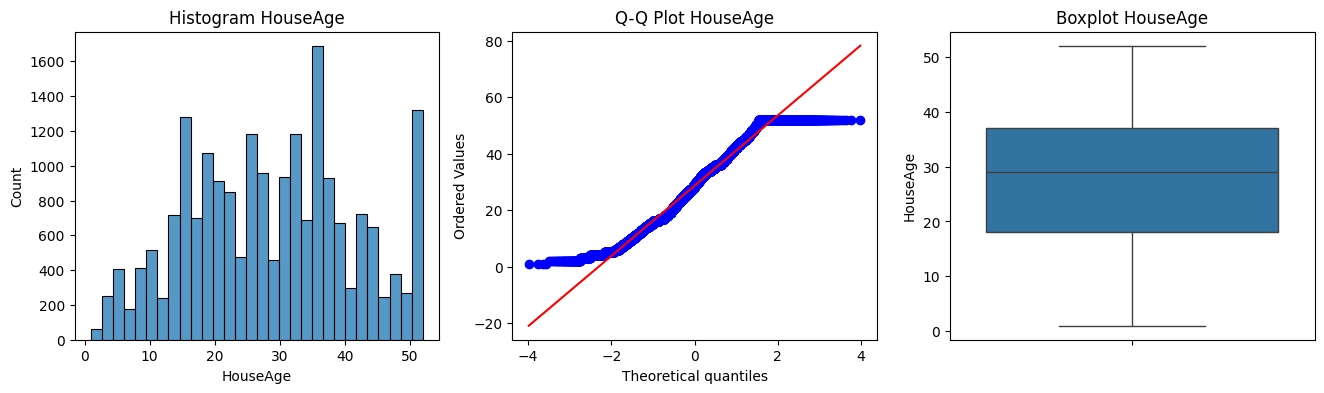

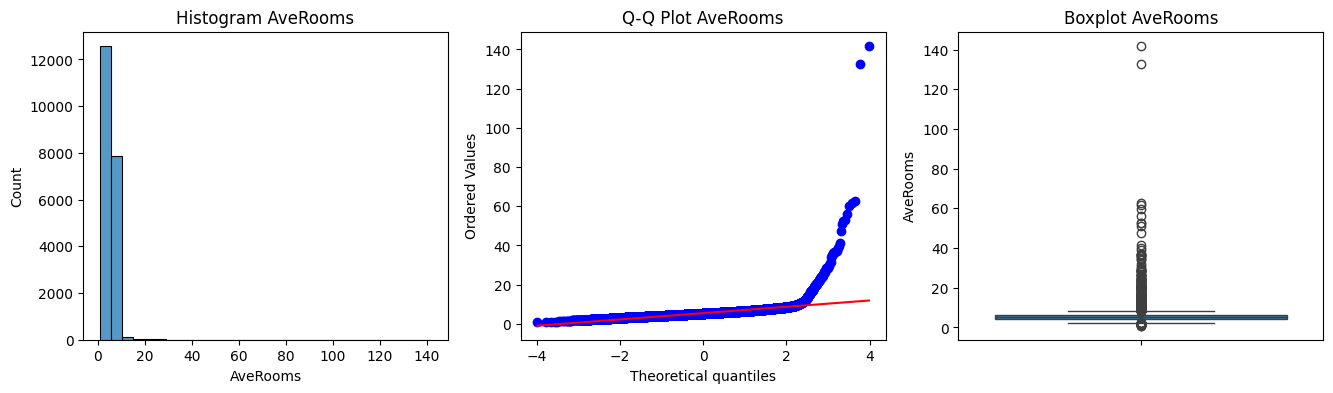

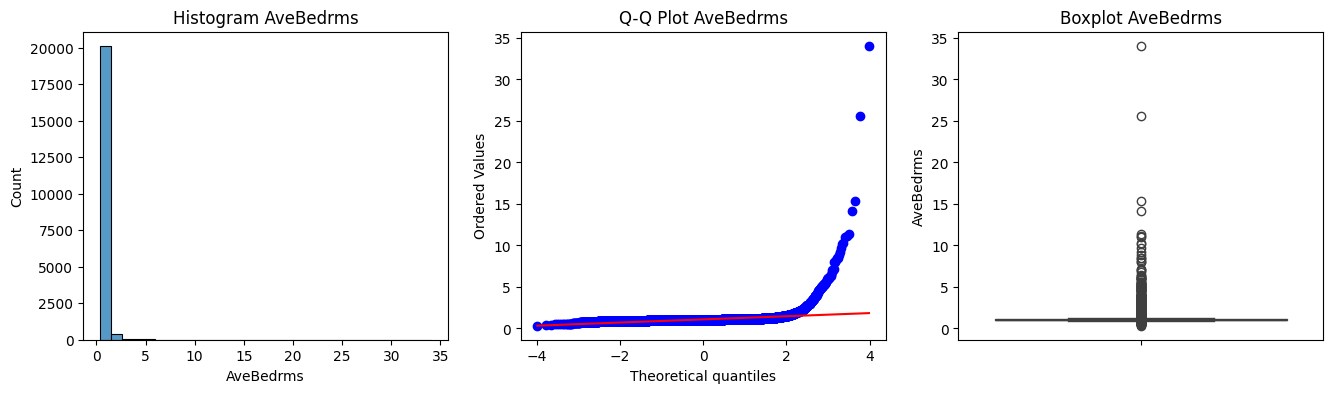

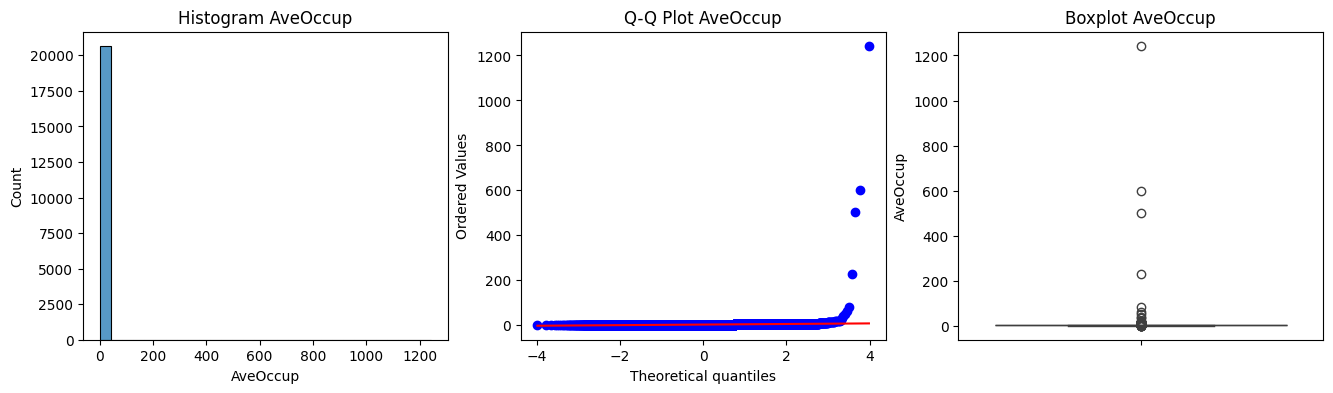

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# membaca dataset
df_california = pd.read_csv("california_dataset.csv")

# daftar kolom yang ingin dicek
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

# looping untuk plot
for kolom in kolom_kolom:
    
    plt.figure(figsize=(16,4))

    # Histogram
    plt.subplot(1,3,1)
    sns.histplot(df_california[kolom], bins=30)
    plt.title(f'Histogram {kolom}')

    # Q-Q Plot
    plt.subplot(1,3,2)
    stats.probplot(df_california[kolom], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot {kolom}')

    # Boxplot
    plt.subplot(1,3,3)
    sns.boxplot(y=df_california[kolom])
    plt.title(f'Boxplot {kolom}')

    plt.show()

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [18]:
def find_outlier_boundary(df, variable):

    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)

    return upper_boundary, lower_boundary

In [22]:
AveRooms_upper_limit, AveRooms_lower_limit = find_outlier_boundary(df_california, 'AveRooms')

print("Upper limit :", AveRooms_upper_limit)
print("Lower limit :", AveRooms_lower_limit)

Upper limit : 8.469878027106942
Lower limit : 2.023219161170969


In [24]:
import numpy as np

df_california['AveRooms'] = np.where(
    df_california['AveRooms'] > AveRooms_upper_limit, AveRooms_upper_limit,
    np.where(
        df_california['AveRooms'] < AveRooms_lower_limit, AveRooms_lower_limit,
        df_california['AveRooms']
    )
)

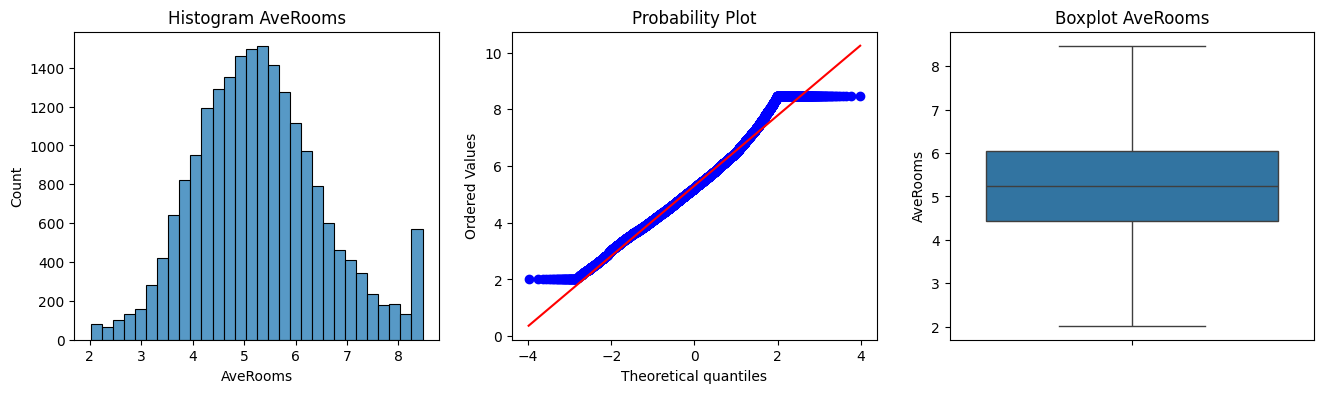

In [26]:
plt.figure(figsize=(16,4))

# Histogram
plt.subplot(1,3,1)
sns.histplot(df_california['AveRooms'], bins=30)
plt.title("Histogram AveRooms")

# QQ Plot
plt.subplot(1,3,2)
stats.probplot(df_california['AveRooms'], dist="norm", plot=plt)

# Boxplot
plt.subplot(1,3,3)
sns.boxplot(y=df_california['AveRooms'])
plt.title("Boxplot AveRooms")

plt.show()

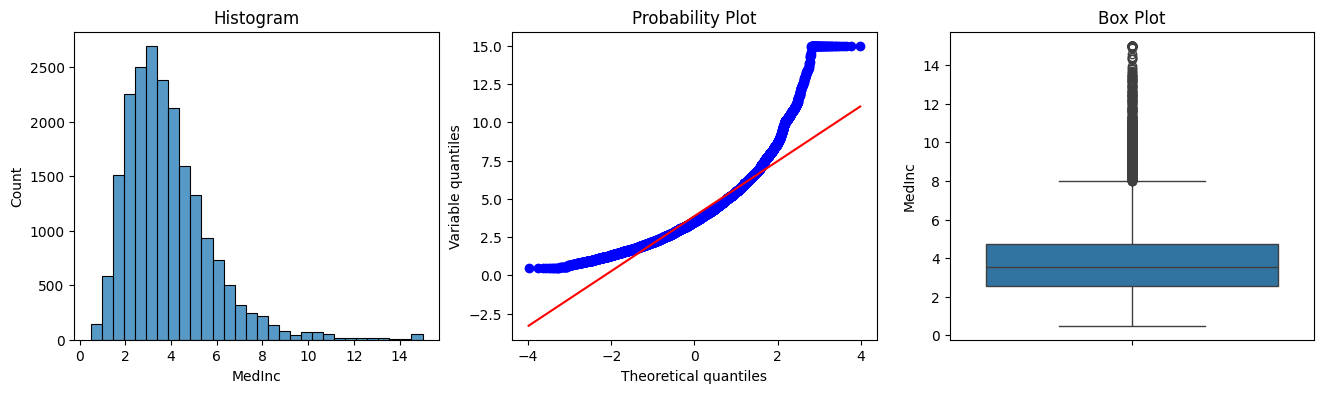

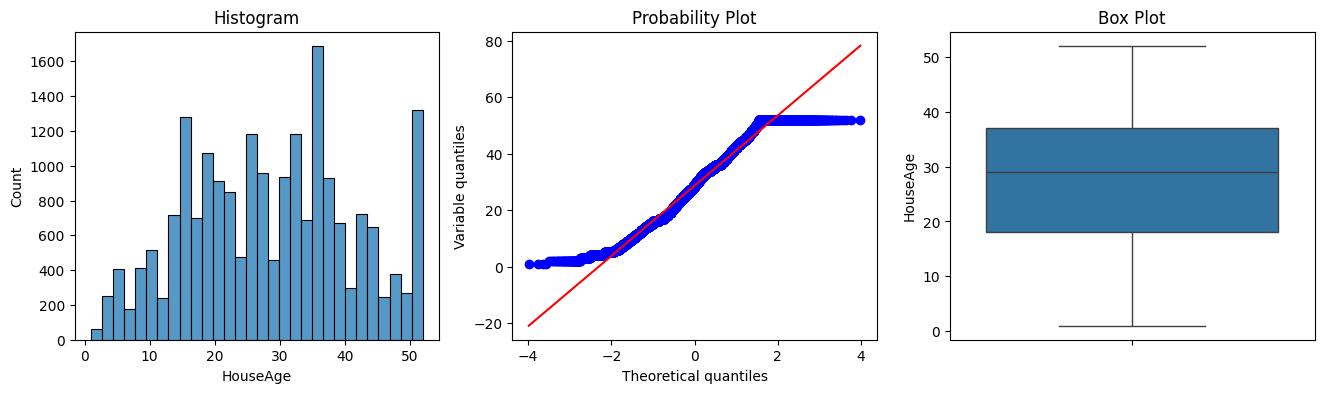

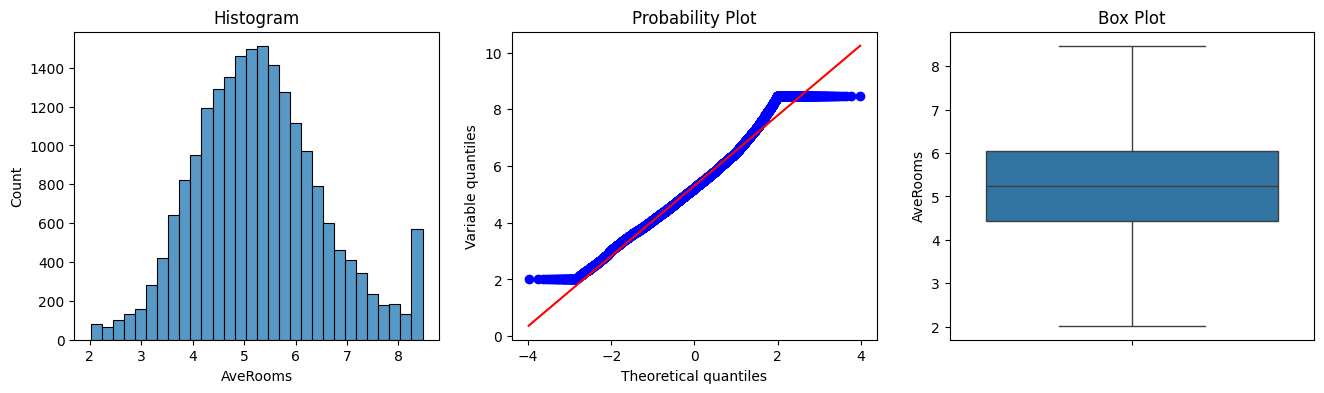

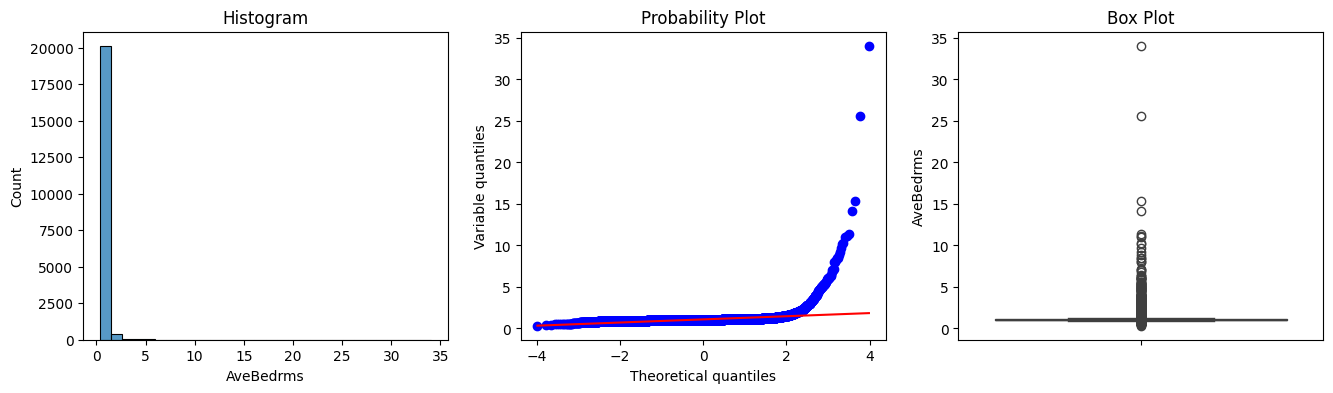

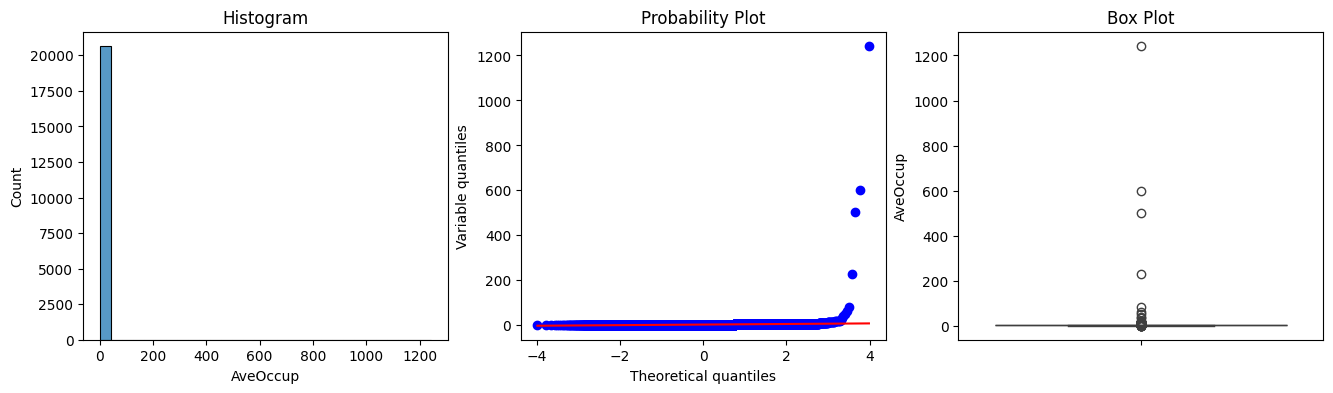

In [27]:
# Melakukan loop untuk mengecek distribusi tiap kolom
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']
for kolom in kolom_kolom:
    plt.figure(figsize=(16, 4))
    
    
    # plot histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df_california[kolom], bins=30)
    plt.title("Histogram")
    
    # plot Q - Q
    plt.subplot(1, 3, 2)
    stats.probplot(df_california[kolom], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')
    
    # bos plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=(df_california[kolom]))
    plt.title("Box Plot")
    
    plt.show

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [ ]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [ ]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [29]:
#Tulis jawaban missing value handling kolom Headquarters disini
df_company = pd.read_csv('company.csv')

In [30]:
df_company.head()

,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,3.1,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


In [31]:
df_company.isna().sum()

Revenue         0
Size            0
Rating          0
Headquarters    0
dtype: int64

In [34]:
missing = df_company['Headquarters'].isnull().sum()
total = len(df_company)

persentase_missing = (missing / total) * 100

print("Jumlah missing value :", missing)
print("Total Data :", total)
print("Persentase missing value :", persentase_missing, "%")

Jumlah missing value : 0
Total Data : 672
Persentase missing value : 0.0 %


In [36]:
for column in df_company.columns:
    print(f"============ {column} ===========")
    display(df_company[column].value_counts())
    print()
    

============ Revenue ===========


Revenue
Unknown / Non-Applicable            213
$100 to $500 million (USD)           94
$10+ billion (USD)                   63
$2 to $5 billion (USD)               45
$10 to $25 million (USD)             41
$1 to $2 billion (USD)               36
$25 to $50 million (USD)             36
$50 to $100 million (USD)            31
$1 to $5 million (USD)               31
-1                                   27
$500 million to $1 billion (USD)     19
$5 to $10 million (USD)              14
Less than $1 million (USD)           14
$5 to $10 billion (USD)               8
Name: count, dtype: int64


============ Size ===========


Size
51 to 200 employees        135
1001 to 5000 employees     104
1 to 50 employees           86
201 to 500 employees        85
10000+ employees            80
501 to 1000 employees       77
5001 to 10000 employees     61
-1                          27
Unknown                     17
Name: count, dtype: int64


============ Rating ===========


Rating
 3.5    58
-1.0    50
 3.3    41
 4.0    41
 3.9    40
 3.8    39
 3.7    38
 5.0    36
 4.5    32
 3.6    31
 3.4    31
 4.2    29
 4.1    25
 4.4    24
 4.7    22
 3.2    21
 4.8    20
 2.9    14
 4.3    14
 3.1    12
 4.6    12
 4.9    11
 2.7    10
 3.0     7
 2.6     4
 2.8     3
 2.5     2
 2.2     1
 2.4     1
 2.3     1
 2.1     1
 2.0     1
Name: count, dtype: int64


============ Headquarters ===========


Headquarters
New York, NY                 33
San Francisco, CA            31
-1                           31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, MA                10
Cambridge, United Kingdom    10
Vienna, VA                    8
Herndon, VA                   7
Bedford, MA                   7
Saint Louis, MO               7
Washington, DC                7
Denver, CO                    7
Arlington, VA                 7
San Jose, CA                  7
Woodbine, MD                  7
Basel, Switzerland            6
Mountain View, CA             6
Chantilly, VA                 6
San Rafael, CA                6
San Antonio, TX               6
Princeton, NJ                 5
Bellevue, WA                  5
Rockville, MD                 5
Bethesda, MD                  5
Fairfax, VA                   5
Springfield, MA               5
Houston, TX                

In [42]:
100 * len(df_company[df_company['Headquarters'].isin(['-1'])]) / len(df_company)

4.613095238095238

In [45]:
mode_headquarters = df_company[df_company['Headquarters'] != '-1']['Headquarters'].mode()[0]

df_company['Headquarters'] = df_company['Headquarters'].replace('-1', mode_headquarters)

In [49]:
mode_headquarters

'New York, NY'

In [51]:
df_company['Rating'] = df_company['Rating'].apply(lambda x: mode_headquarters if x==-1 else x)
df_company['Rating'] = df_company['Rating'].apply(lambda x: mode_headquarters if x==-1 else x)

In [52]:
df_company['Headquarters'].value_counts()

Headquarters
New York, NY                 64
San Francisco, CA            31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, MA                10
Cambridge, United Kingdom    10
Vienna, VA                    8
Herndon, VA                   7
Bedford, MA                   7
Saint Louis, MO               7
Washington, DC                7
Denver, CO                    7
Arlington, VA                 7
San Jose, CA                  7
Woodbine, MD                  7
Basel, Switzerland            6
Mountain View, CA             6
Chantilly, VA                 6
San Rafael, CA                6
San Antonio, TX               6
Princeton, NJ                 5
Bellevue, WA                  5
Rockville, MD                 5
Bethesda, MD                  5
Fairfax, VA                   5
Springfield, MA               5
Houston, TX                   5
Pittsburgh, PA             

# 2. Assignment 2 – Missing Value Handling

Pada kolom **Headquarters** ditemukan nilai **“-1”** yang digunakan sebagai penanda missing value. Nilai tersebut kemudian diperlakukan sebagai data yang hilang sehingga dapat dihitung dalam proses analisis missing value.

Berdasarkan hasil perhitungan, persentase missing value pada kolom **Headquarters** adalah sekitar **4.6%** dari keseluruhan data. Berdasarkan ketentuan yang digunakan dalam tugas ini, kolom akan dihapus apabila persentase missing value lebih dari **20%**. Karena persentase missing value pada kolom **Headquarters** masih berada di bawah batas tersebut, maka kolom **tidak dihapus (tidak di-drop)**.

Selanjutnya dilakukan proses **handling missing value**. Karena kolom **Headquarters** merupakan data **kategorikal** yang berisi nama lokasi kantor pusat perusahaan, maka metode yang digunakan untuk mengisi nilai yang hilang adalah **modus (mode)**, yaitu nilai yang paling sering muncul pada kolom tersebut. Dengan metode ini, nilai **“-1”** digantikan dengan nilai yang paling sering muncul sehingga data menjadi lebih konsisten dan dapat digunakan untuk proses analisis atau pemodelan selanjutnya.


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [60]:
df_churn = pd.read_csv("TelcoCustomerChurn.csv")

In [61]:
from sklearn.model_selection import train_test_split

train_churn, test_churn = train_test_split(
    df_churn,
    test_size=0.2,
    random_state=42
)

In [62]:
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [63]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder

# Kolom yang ingin saya encode
column_to_encode = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

label_encoder = LabelEncoder()

In [64]:
#Cek nilai-nilai di kolom kategorikal
for column in column_to_encode:
    print(f"============= {column} =================")
    display(df_churn[column].value_counts())
    print()

============= StreamingMovies =================


StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


============= StreamingTV =================


StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64


============= TechSupport =================


...

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


============= OnlineSecurity =================


OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


============= MultipleLines =================


MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [65]:
df_churn['StreamingMovies'] = df_churn['StreamingMovies'].replace({'No internet service':'No'})
df_churn['StreamingTV'] = df_churn['StreamingTV'].replace({'No internet service':'No'})
df_churn['TechSupport'] = df_churn['TechSupport'].replace({'No internet service':'No'})
df_churn['DeviceProtection'] = df_churn['DeviceProtection'].replace({'No internet service':'No'})
df_churn['OnlineBackup'] = df_churn['OnlineBackup'].replace({'No internet service':'No'})
df_churn['OnlineSecurity'] = df_churn['OnlineSecurity'].replace({'No internet service':'No'})
df_churn['MultipleLines'] = df_churn['MultipleLines'].replace({'No phone service':'No'})
train_churn['MultipleLines'] = train_churn['MultipleLines'].replace({'No phone service':'No'})
test_churn['MultipleLines'] = test_churn['MultipleLines'].replace({'No phone service':'No'})

cols = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

for col in cols:
    train_churn[col] = train_churn[col].replace({'No internet service':'No'})
    test_churn[col] = test_churn[col].replace({'No internet service':'No'})

In [68]:
#Cek nilai-nilai di kolom kategorikal
for column in column_to_encode:
    print(f"============= {column} =================")
    display(df_churn[column].value_counts())
    print()

============= StreamingMovies =================


StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64


============= StreamingTV =================


StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64


============= TechSupport =================


...

OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64


============= OnlineSecurity =================


OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64


============= MultipleLines =================


MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64

In [69]:
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [70]:
train_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2142,4223-BKEOR,Female,0,No,Yes,21,Yes,No,DSL,Yes,No,Yes,No,No,Yes,One year,No,Mailed check,64.85,1336.8,No
1623,6035-RIIOM,Female,0,No,No,54,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),97.20,5129.45,No
6074,3797-VTIDR,Male,0,Yes,No,1,No,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,23.45,23.45,Yes
1362,2568-BRGYX,Male,0,No,No,4,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.20,237.95,Yes
6754,2775-SEFEE,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,,No


In [71]:
test_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No,No,No,No,No,No,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


## Selesai :)